
# INTRODUCCIÓN
- **Descripción del problema seleccionado:**  
  Desarrollar un modelo de Machine Learning capaz de predecir la demanda horaria de un sistema de bicicletas compartidas, utilizando variables temporales, de calendario y meteorológicas. El problema se basa en los datos históricos del sistema Capital Bikeshare de Washington D. C., con 17.379 registros horarios correspondientes a los años 2011 y 2012.

- **Definición del objetivo del modelo:**  
  Desarrollar un modelo de Machine Learning capaz de predecir la cantidad de bicicletas que serán alquiladas durante una determinada hora, a partir de variables temporales, de calendario y meteorológicas.

-  **Tipo de problema (clasificación / regresión):**  
  **Regresión**, debido a que el modelo debe predecir un valor numérico continuo correspondiente a la cantidad de alquileres de bicicletas durante una hora determinada.

- **Identificación de la variable objetivo:**  
  La variable objetivo es **`cnt`**, que representa el número total de alquileres de bicicletas realizados durante cada hora. Esta variable corresponde a la suma de los usuarios casuales (`casual`) y registrados (`registered`).

- **Fuente de los datos:**  
  El conjunto de datos utilizado corresponde al histórico del sistema **Capital Bikeshare** y fue obtenido desde Kaggle:  
  https://www.kaggle.com/datasets/amil09/bike-sharing-dataset/data?select=Bike+Share+hourly.csv


  # Descripción del conjunto de datos



  

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline

#Carga de dataframe
import pandas as pd

df = pd.read_excel("data/Bike_Share_hourly.csv")
df = df.iloc[:, 0].astype(str).str.split(",", expand=True)
df.columns = [
    "instant",
    "dteday",
    "season",
    "yr",
    "mnth",
    "hr",
    "holiday",
    "weekday",
    "workingday",
    "weathersit",
    "temp",
    "atemp",
    "hum",
    "windspeed",
    "casual",
    "registered",
    "cnt"
]


In [3]:
#Número de observaciones corresponde a 17379
df.shape[0]

17379

In [4]:
#Número de variables corresponde a 17
df.shape[1]

17

**Significado de la variable objetivo:** Para este proyecto la variable objetivo es llamada "cnt", el conteo total de alquileres por hora, resultado de sumar los usuarios casuales (casual) y los registrados (registered). Precisamente por ser una suma exacta de estas dos columnas, casual y registered se excluirán como variables predictoras: usarlas equivaldría a filtrar información directa del resultado, lo cual invalidaría cualquier métrica de desempeño obtenida.

**Tipos de variables:** En el análisis inicial del conjunto de datos se identificaron 17 variables, todas clasificadas actualmente por Pandas como tipo object. Esto indica que los datos fueron cargados como texto y, antes de construir el modelo de Machine Learning, será necesario revisar y convertir las variables numéricas a sus tipos correspondientes, además de tratar adecuadamente variables como dteday, que representa una fecha.

In [5]:
for columna in df.columns:
    print(columna, "->", df[columna].dtype)

instant -> object
dteday -> object
season -> object
yr -> object
mnth -> object
hr -> object
holiday -> object
weekday -> object
workingday -> object
weathersit -> object
temp -> object
atemp -> object
hum -> object
windspeed -> object
casual -> object
registered -> object
cnt -> object


**Posibles limitaciones del dataset:** El dataset puede presentar algunas limitaciones, como la necesidad de convertir correctamente los tipos de datos, posibles valores faltantes o inconsistencias y la representación limitada de factores externos que pueden afectar la demanda de bicicletas, como eventos especiales, condiciones económicas o cambios en los hábitos de los usuarios. Además, los datos corresponden a un período específico, por lo que los patrones identificados podrían no representar completamente el comportamiento en otros períodos o contextos.

# Exploración de los datos

In [6]:
#Dimensiones del dataset: El conjunto de datos tiene 17379 observaciones y 17 variables.
df.shape

(17379, 17)

In [9]:
#Identificación y cuantificación de valores faltantes por variable: Actualmente no hay valores faltantes en el conjunto de datos. Sin embargo, se agregaran valores faltantes para poder realizar los respectivos procesos de normalizacion de datos.
df.isnull().sum()

instant       0
dteday        0
season        0
yr            0
mnth          0
hr            0
holiday       0
weekday       0
workingday    0
weathersit    0
temp          0
atemp         0
hum           0
windspeed     0
casual        0
registered    0
cnt           0
dtype: int64

In [10]:
#Estadísticas descriptivas: El resultado muestra que el dataset contiene 17.379 registros y 17 variables, sin datos faltantes en ninguna columna. Además, se observa que algunas variables son categóricas y presentan un número limitado de valores únicos, como season con 4 y mnth con 12, mientras que variables como instant tienen valores únicos para cada registro. La columna workingday presenta como valor más frecuente 1, con 11.865 registros, y holiday tiene como valor más frecuente 0, con 16.879 registros, lo que indica que la mayoría de los registros corresponden a días laborales y no festivos.
df.describe()

,instant,dteday,season,yr,mnth,hr,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
count,17379,17379,17379,17379,17379,17379,17379,17379,17379,17379,17379,17379,17379,17379,17379,17379,17379
unique,17379,731,4,2,12,24,2,7,2,4,50,65,89,30,322,776,869
top,1,2012-12-31,3,1,7,16,0,6,1,1,0.62,0.6212,0.88,0,0,4,5
freq,1,24,4496,8734,1488,730,16879,2512,11865,11413,726,988,657,2180,1581,307,260


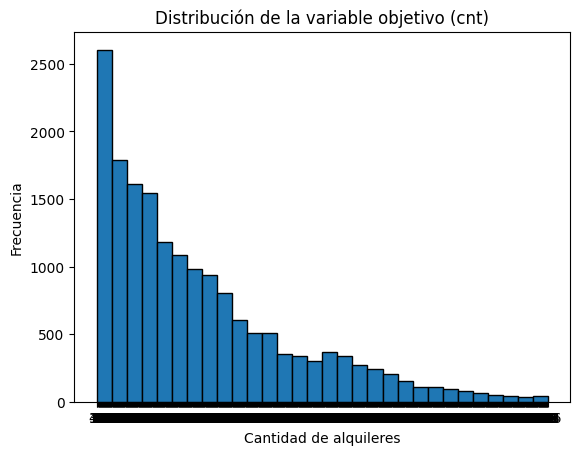

In [12]:
#Distribución de la variable objetivo: La gráfica muestra que la variable objetivo cnt presenta una distribución asimétrica hacia la derecha, ya que la mayor concentración de registros se encuentra en valores bajos de alquileres y la frecuencia disminuye progresivamente a medida que aumenta la cantidad de alquileres. También se observan algunos valores altos con menor frecuencia, lo que puede indicar la presencia de valores extremos en el dataset.

plt.hist(df['cnt'], bins=30, edgecolor='black')
plt.xlabel('Cantidad de alquileres')
plt.ylabel('Frecuencia')
plt.title('Distribución de la variable objetivo (cnt)')
plt.show()

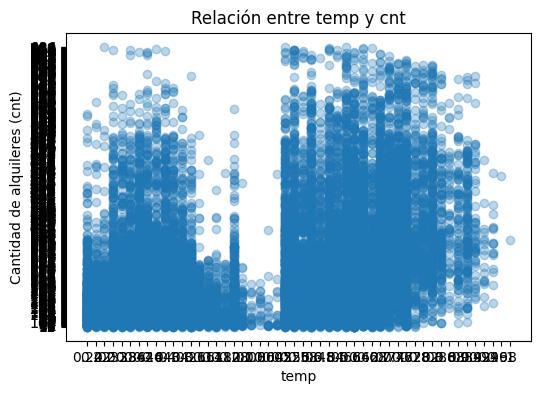

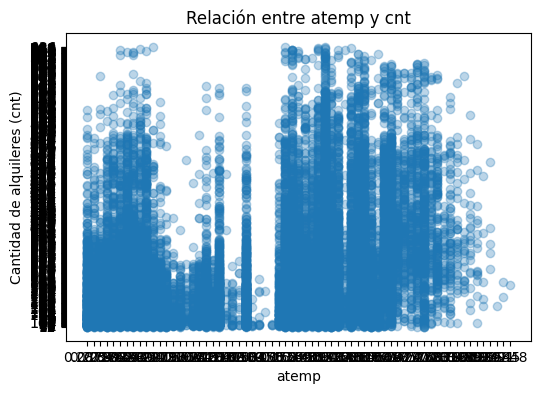

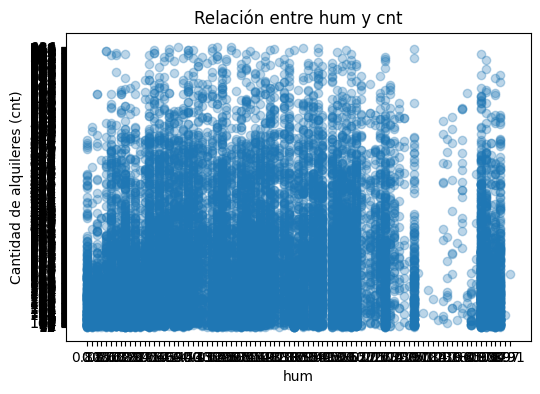

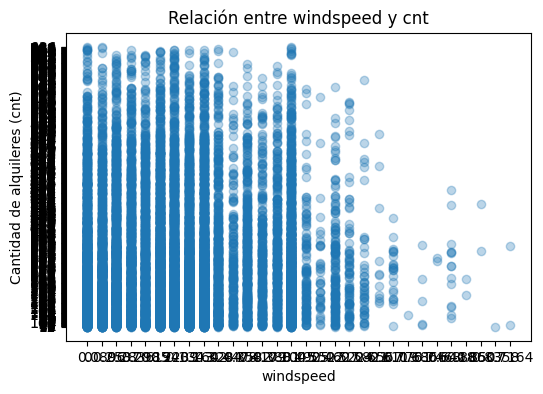

In [13]:
#Análisis de relaciones entre variables predictoras y la variable objetivo: Inicialmente se realiza el anlisis sin ningun tratamiento de los datos, y se anlizan las que se consideran variables numericas, que son temp, atemp, hum y windspeed. Como resultado de los graficos se observa que la variable temp tiene una relación positiva con la variable objetivo cnt, es decir, a medida que aumenta la temperatura, también aumenta la cantidad de alquileres, aunque con una disminución en la zona media de la temperatura. Por otro lado, las variables atemp, hum y windspeed presentan una relación negativa con la variable objetivo cnt hacia la derecha, lo que indica que a medida que aumentan estas variables, disminuye la cantidad de alquileres.

variables_numericas = ['temp', 'atemp', 'hum', 'windspeed']

for variable in variables_numericas:
    plt.figure(figsize=(6, 4))
    plt.scatter(df[variable], df['cnt'], alpha=0.3)
    
    plt.xlabel(variable)
    plt.ylabel('Cantidad de alquileres (cnt)')
    plt.title(f'Relación entre {variable} y cnt')
    
    plt.show()

                temp     atemp       hum  windspeed    casual  registered  \
temp        1.000000  0.987672 -0.069881  -0.023125  0.459616    0.335361   
atemp       0.987672  1.000000 -0.051918  -0.062336  0.454080    0.332559   
hum        -0.069881 -0.051918  1.000000  -0.290105 -0.347028   -0.273933   
windspeed  -0.023125 -0.062336 -0.290105   1.000000  0.090287    0.082321   
casual      0.459616  0.454080 -0.347028   0.090287  1.000000    0.506618   
registered  0.335361  0.332559 -0.273933   0.082321  0.506618    1.000000   
cnt         0.404772  0.400929 -0.322911   0.093234  0.694564    0.972151   

                 cnt  
temp        0.404772  
atemp       0.400929  
hum        -0.322911  
windspeed   0.093234  
casual      0.694564  
registered  0.972151  
cnt         1.000000  


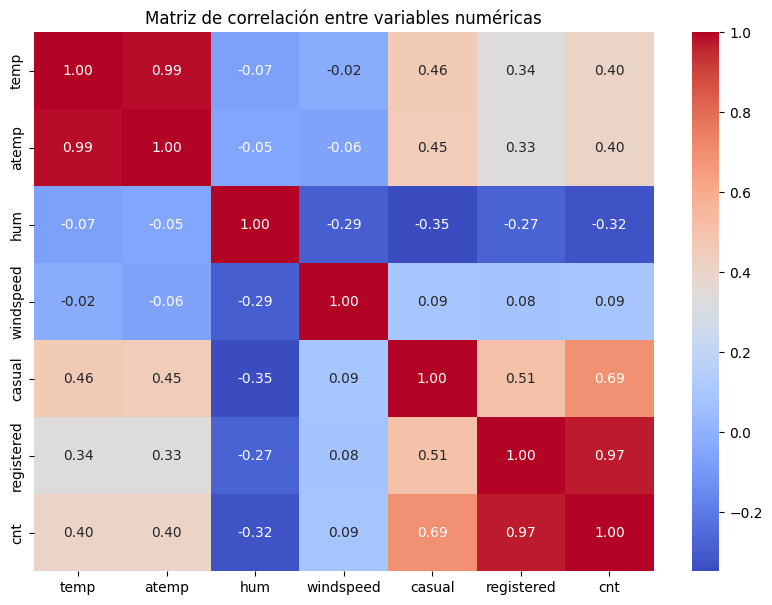

In [14]:
#Análisis de correlación entre variables numéricas: En el gráfico destacan asociaciones fuertemente positivas en tonos rojos oscuros, principalmente casi perfectas entre la temperatura real y la sensación térmica ($0.99$), así como entre los usuarios registrados y el total de alquileres ($0.97$). Por otro lado, las variables ambientales como la humedad y el viento muestran correlaciones débiles o negativas respecto al uso del servicio, representadas en tonos azules.

import seaborn as sns


# Seleccionar variables numéricas
variables_numericas = [
    'temp',
    'atemp',
    'hum',
    'windspeed',
    'casual',
    'registered',
    'cnt'
]

# Calcular matriz de correlación
correlacion = df[variables_numericas].corr()

# Mostrar matriz
print(correlacion)

# Graficar mapa de calor
plt.figure(figsize=(10, 7))

sns.heatmap(
    correlacion,
    annot=True,
    cmap='coolwarm',
    fmt='.2f'
)

plt.title('Matriz de correlación entre variables numéricas')
plt.show()

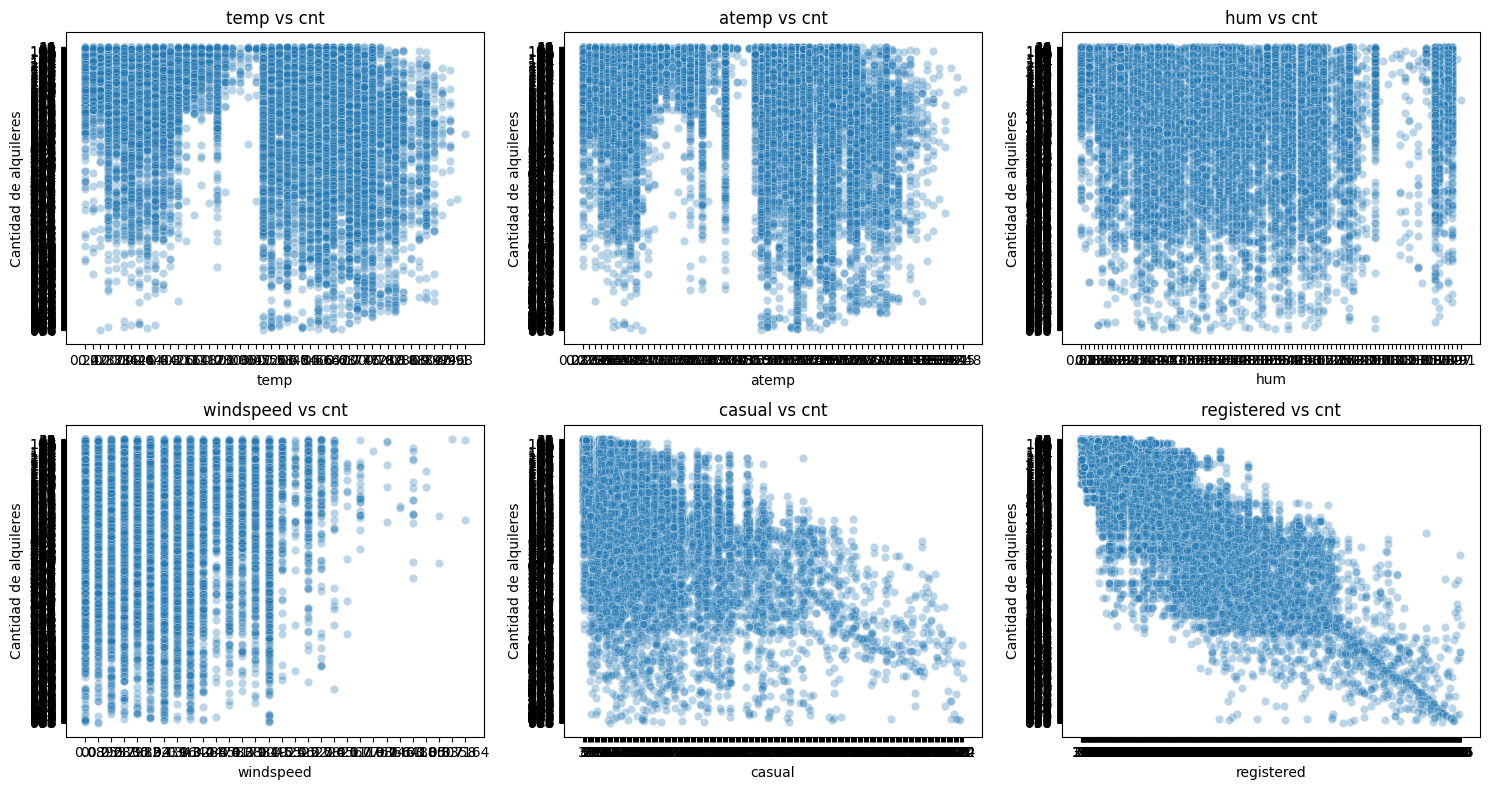

In [15]:
#Visualizaciones relevantes y útiles

variables = ['temp', 'atemp', 'hum', 'windspeed', 'casual', 'registered']

fig, axes = plt.subplots(2, 3, figsize=(15, 8))

for ax, variable in zip(axes.flatten(), variables):
    sns.scatterplot(
        data=df,
        x=variable,
        y='cnt',
        alpha=0.3,
        ax=ax
    )
    
    ax.set_title(f'{variable} vs cnt')
    ax.set_xlabel(variable)
    ax.set_ylabel('Cantidad de alquileres')

plt.tight_layout()
plt.show()

In [16]:
#Decisión justificada sobre variables altamente correlacionadas:Se revisaron las correlaciones entre las variables numéricas para identificar posibles problemas de redundancia. Debido a la alta relación esperada entre temp y atemp, se evaluará la posibilidad de conservar únicamente una de estas variables para reducir la redundancia. Además, casual y registered se excluyen como variables predictoras, debido a que cnt corresponde a la suma de ambas variables, lo que generaría fuga de información hacia el modelo.
correlacion = df[['temp', 'atemp', 'hum', 'windspeed','casual','registered']].corr()

print(correlacion)

                temp     atemp       hum  windspeed    casual  registered
temp        1.000000  0.987672 -0.069881  -0.023125  0.459616    0.335361
atemp       0.987672  1.000000 -0.051918  -0.062336  0.454080    0.332559
hum        -0.069881 -0.051918  1.000000  -0.290105 -0.347028   -0.273933
windspeed  -0.023125 -0.062336 -0.290105   1.000000  0.090287    0.082321
casual      0.459616  0.454080 -0.347028   0.090287  1.000000    0.506618
registered  0.335361  0.332559 -0.273933   0.082321  0.506618    1.000000


In [7]:
# Imports y configuración global

In [8]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import json
import os
from pathlib import Path

# Modelado
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder, FunctionTransformer
from sklearn.impute import SimpleImputer
from sklearn.linear_model import Ridge
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import joblib

# Reproducibilidad
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

# Configuración de gráficas
sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (10, 5)
plt.rcParams["figure.dpi"] = 100

# Rutas relativas al notebook
BASE_DIR = Path.cwd().parent.parent  # raíz del repo
DATA_RAW = BASE_DIR / "data" / "raw" / "Bike_Share_hourly.csv"
DATA_PROCESSED = BASE_DIR / "data" / "processed"
MODELS_DIR = BASE_DIR / "fase-1" / "models"
FIGURES_DIR = BASE_DIR / "fase-1" / "reports" / "figures"

# Crear las carpetas si no existen
for d in [DATA_PROCESSED, MODELS_DIR, FIGURES_DIR]:
    d.mkdir(parents=True, exist_ok=True)

ModuleNotFoundError: No module named 'sklearn'

In [ ]:
# Carga del dataset

In [ ]:
df = pd.read_csv(DATA_RAW)

print(f"Shape: {df.shape}")
print(f"Columnas: {list(df.columns)}")
df.head()

In [ ]:
# Auditoría inicial: nulos, tipos, duplicados

In [ ]:
print("=== Nulos por columna (dataset original) ===")
print(df.isnull().sum())

print("\n=== Tipos de datos ===")
print(df.dtypes)

print(f"\n=== Filas duplicadas: {df.duplicated().sum()} ===")
print(f"=== Registros totales: {len(df)} ===")